# Analisis Hasil Eksperimen Fairness Lambda

Input: `fairness_lambda_experiment_summary.csv`

1. Membaca hasil eksperimen lambda/fairness.
2. Menghitung rata-rata metrik pada semua K untuk setiap nilai lambda.
3. Membuat satu visualisasi untuk melihat nilai lambda terbaik berdasarkan masing-masing metrik.


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

INPUT_FILE = Path("fairness_lambda_experiment_summary.csv")
OUTPUT_DIR = Path("analysis_fairness_lambda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(INPUT_FILE, sep=None, engine="python")
df.columns = df.columns.str.replace("\ufeff", "", regex=False)

print(f"Data dimuat: {df.shape[0]} baris x {df.shape[1]} kolom")
display(df.head())

Data dimuat: 5 baris x 71 kolom


,experiment_id,experiment_name,source_model,num_queries,mean_candidate_count,mean_total_relevant_in_model,popularity_id,popularity_features,value_id,value_features,...,mean_fairness@50,mean_f1@50,mean_tp@60,mean_fp@60,mean_fn@60,mean_precision@60,mean_recall@60,mean_ndcg@60,mean_fairness@60,mean_f1@60
0,1,L0p1_B7_countSold_countReview_totalRating__G3_...,relevance,10,70.0,57.5,B7_countSold_countReview_totalRating,countSold + countReview + totalRating,G3_ratingAverage_discountPercentage,ratingAverage + discountPercentage,...,0.686,0.788172,50.7,9.3,6.8,0.845000,0.887114,0.941090,0.631667,0.851016
1,2,L0p2_B7_countSold_countReview_totalRating__G3_...,relevance,10,70.0,57.5,B7_countSold_countReview_totalRating,countSold + countReview + totalRating,G3_ratingAverage_discountPercentage,ratingAverage + discountPercentage,...,0.730,0.787781,50.5,9.5,7.0,0.841667,0.878380,0.930775,0.663333,0.845825
2,3,L0p3_B7_countSold_countReview_totalRating__G3_...,relevance,10,70.0,57.5,B7_countSold_countReview_totalRating,countSold + countReview + totalRating,G3_ratingAverage_discountPercentage,ratingAverage + discountPercentage,...,0.772,0.779563,50.8,9.2,6.7,0.846667,0.882040,0.927032,0.685000,0.850470
3,4,L0p4_B7_countSold_countReview_totalRating__G3_...,relevance,10,70.0,57.5,B7_countSold_countReview_totalRating,countSold + countReview + totalRating,G3_ratingAverage_discountPercentage,ratingAverage + discountPercentage,...,0.786,0.767193,50.5,9.5,7.0,0.841667,0.870929,0.913002,0.695000,0.843574
4,5,L0p5_B7_countSold_countReview_totalRating__G3_...,relevance,10,70.0,57.5,B7_countSold_countReview_totalRating,countSold + countReview + totalRating,G3_ratingAverage_discountPercentage,ratingAverage + discountPercentage,...,0.788,0.764596,50.5,9.5,7.0,0.841667,0.870929,0.914657,0.695000,0.843574


## Konfigurasi metrik dan K

In [12]:
METRICS = ["precision", "recall", "ndcg", "fairness", "f1"]
K_VALUES = [10, 20, 30, 40, 45, 50, 60]

metric_cols = {
    metric: [f"mean_{metric}@{k}" for k in K_VALUES]
    for metric in METRICS
}

missing_cols = [
    col
    for cols in metric_cols.values()
    for col in cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(f"Kolom metrik berikut tidak ditemukan: {missing_cols}")

if "lambda" not in df.columns:
    raise ValueError("Kolom 'lambda' tidak ditemukan di file input.")

print("Semua kolom metrik tersedia.")


Semua kolom metrik tersedia.


## Ringkasan rata-rata metrik per lambda

In [14]:
def summarize_by_lambda(data: pd.DataFrame) -> pd.DataFrame:
    temp = data.copy()

    for metric, cols in metric_cols.items():
        temp[f"avg_{metric}"] = temp[cols].mean(axis=1)

    avg_cols = [f"avg_{metric}" for metric in METRICS]

    summary = (
        temp.groupby("lambda", as_index=False)[avg_cols]
        .mean()
        .sort_values("lambda")
        .reset_index(drop=True)
    )

    baseline = summary.loc[summary["lambda"].eq(0.0)]

    if not baseline.empty:
        baseline = baseline.iloc[0]

        for metric in METRICS:
            col = f"avg_{metric}"
            summary[f"delta_{metric}_vs_lambda_0"] = summary[col] - baseline[col]

    return summary


lambda_summary = summarize_by_lambda(df)

lambda_summary.to_csv(
    OUTPUT_DIR / "01_lambda_summary_avg_metrics_allK.csv",
    index=False,
    encoding="utf-8-sig",
)

display(lambda_summary)


,lambda,avg_precision,avg_recall,avg_ndcg,avg_fairness,avg_f1
0,0.1,0.899317,0.568128,0.927660,0.739111,0.649162
1,0.2,0.886103,0.554784,0.910001,0.813571,0.636595
2,0.3,0.875444,0.545888,0.893818,0.855405,0.627993
3,0.4,0.868778,0.538146,0.876801,0.875222,0.621319
4,0.5,0.862857,0.534826,0.876206,0.878246,0.617510


In [9]:
# =========================================================
# ANALISIS DELTA DETAIL (KENAikan / PENURUNAN)
# =========================================================

analysis_df = lambda_summary.copy()

metrics = ["precision", "recall", "ndcg", "fairness", "f1"]

delta_results = []

for i in range(1, len(analysis_df)):
    prev = analysis_df.iloc[i - 1]
    curr = analysis_df.iloc[i]

    row = {
        "lambda_from": prev["lambda"],
        "lambda_to": curr["lambda"],
    }

    for m in metrics:
        col = f"avg_{m}_allK"

        delta = curr[col] - prev[col]
        #delta_pct = (delta / prev[col]) * 100 if prev[col] != 0 else 0

        # klasifikasi signifikansi
        abs_delta = abs(delta)

        if abs_delta >= 0.05:
            label = "SIGNIFIKAN"
        elif abs_delta >= 0.02:
            label = "MODERATE"
        else:
            label = "FLUKTUASI KECIL"

        row[f"selisih_{m}"] = delta
        #row[f"delta_pct_{m}"] = delta_pct
        row[f"impact_{m}"] = label

    delta_results.append(row)

delta_df = pd.DataFrame(delta_results)

display(delta_df)

# optional save
delta_df.to_csv(
    OUTPUT_DIR / "05_lambda_delta_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

,lambda_from,lambda_to,selisih_precision,impact_precision,selisih_recall,impact_recall,selisih_ndcg,impact_ndcg,selisih_fairness,impact_fairness,selisih_f1,impact_f1
0,0.1,0.2,-0.013214,FLUKTUASI KECIL,-0.013344,FLUKTUASI KECIL,-0.017659,FLUKTUASI KECIL,0.074460,SIGNIFIKAN,-0.012567,FLUKTUASI KECIL
1,0.2,0.3,-0.010659,FLUKTUASI KECIL,-0.008896,FLUKTUASI KECIL,-0.016182,FLUKTUASI KECIL,0.041833,MODERATE,-0.008602,FLUKTUASI KECIL
2,0.3,0.4,-0.006667,FLUKTUASI KECIL,-0.007742,FLUKTUASI KECIL,-0.017017,FLUKTUASI KECIL,0.019817,FLUKTUASI KECIL,-0.006674,FLUKTUASI KECIL
3,0.4,0.5,-0.005921,FLUKTUASI KECIL,-0.003320,FLUKTUASI KECIL,-0.000596,FLUKTUASI KECIL,0.003024,FLUKTUASI KECIL,-0.003809,FLUKTUASI KECIL


## Lambda terbaik

In [6]:
best_lambda_rows = []

for metric in METRICS:
    col = f"avg_{metric}_allK"
    best_idx = lambda_summary[col].idxmax()

    best_lambda_rows.append({
        "metric": metric,
        "best_lambda": lambda_summary.loc[best_idx, "lambda"],
        "best_value": lambda_summary.loc[best_idx, col],
    })

best_lambda_by_metric = pd.DataFrame(best_lambda_rows)

best_lambda_by_metric.to_csv(
    OUTPUT_DIR / "02_best_lambda_by_each_metric.csv",
    index=False,
    encoding="utf-8-sig",
)

display(best_lambda_by_metric)

,metric,best_lambda,best_value
0,precision,0.1,0.899317
1,recall,0.1,0.568128
2,ndcg,0.1,0.927660
3,fairness,0.5,0.878246
4,f1,0.1,0.649162


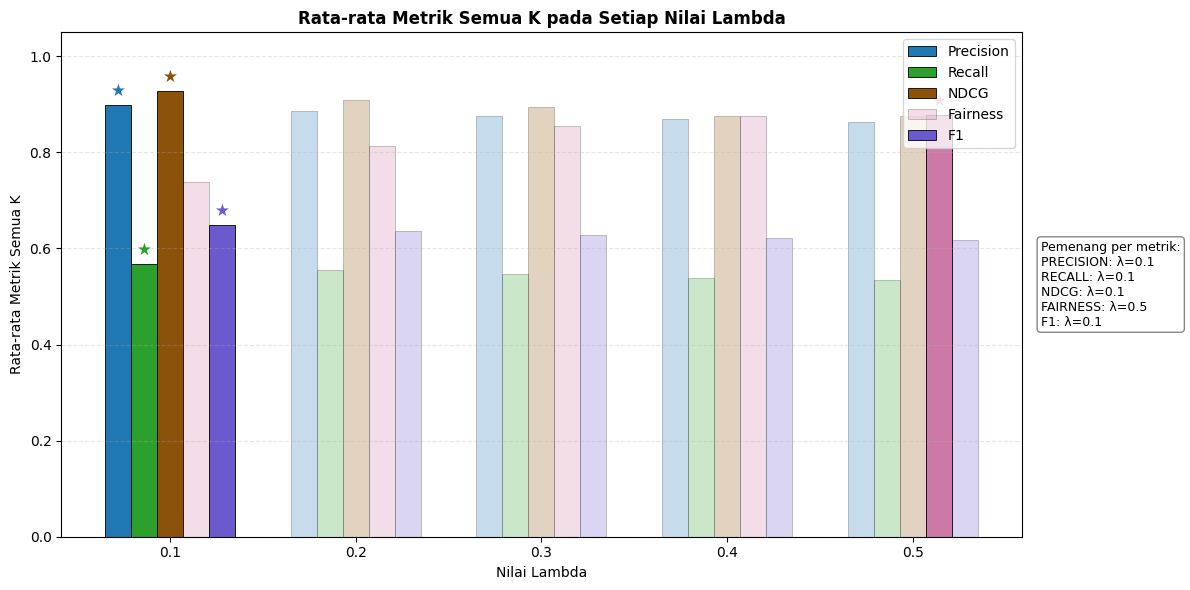

Plot disimpan ke: analysis_fairness_lambda_outputs\04_lambda_metric_grouped_bar_highlight.png


In [7]:
plot_cols = [
    "avg_precision_allK",
    "avg_recall_allK",
    "avg_ndcg_allK",
    "avg_fairness_allK",
    "avg_f1_allK",
]

plot_labels = ["Precision", "Recall", "NDCG", "Fairness", "F1"]

base_colors = {
    "Precision": "#1f77b4",
    "Recall": "#2ca02c",
    "NDCG": "#8c510a",
    "Fairness": "#cc79a7",
    "F1": "#6a5acd",
}

lambda_values = lambda_summary["lambda"].to_numpy()
x = np.arange(len(lambda_values))

bar_width = 0.14

plt.figure(figsize=(12, 6))

best_lambda_text = []

for i, (col, label) in enumerate(zip(plot_cols, plot_labels)):
    offset = (i - (len(plot_cols) - 1) / 2) * bar_width

    best_idx = lambda_summary[col].idxmax()
    best_pos = lambda_summary.index.get_loc(best_idx)
    best_lambda = lambda_summary.loc[best_idx, "lambda"]
    best_value = lambda_summary.loc[best_idx, col]

    colors = []
    alphas = []

    for idx in lambda_summary.index:
        if idx == best_idx:
            colors.append(base_colors[label])
            alphas.append(1.0)
        else:
            colors.append(base_colors[label])
            alphas.append(0.25)

    bars = plt.bar(
        x + offset,
        lambda_summary[col],
        width=bar_width,
        label=label,
        color=colors,
        edgecolor="black",
        linewidth=0.6,
    )

    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)

    best_lambda_text.append(
        f"{label.upper()}: λ={best_lambda}"
    )

    plt.text(
        x[best_pos] + offset,
        best_value + 0.01,
        "★",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=base_colors[label],
    )

plt.title("Rata-rata Metrik Semua K pada Setiap Nilai Lambda", fontweight="bold")
plt.xlabel("Nilai Lambda")
plt.ylabel("Rata-rata Metrik Semua K")
plt.xticks(x, lambda_values)
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.legend(loc="upper right")

winner_text = "Pemenang per metrik:\n" + "\n".join(best_lambda_text)

plt.text(
    1.02,
    0.50,
    winner_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    va="center",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95,
    ),
)

plt.tight_layout()

output_path = OUTPUT_DIR / "04_lambda_metric_grouped_bar_highlight.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Plot disimpan ke:", output_path)

## Visualisasi perbandingan lambda

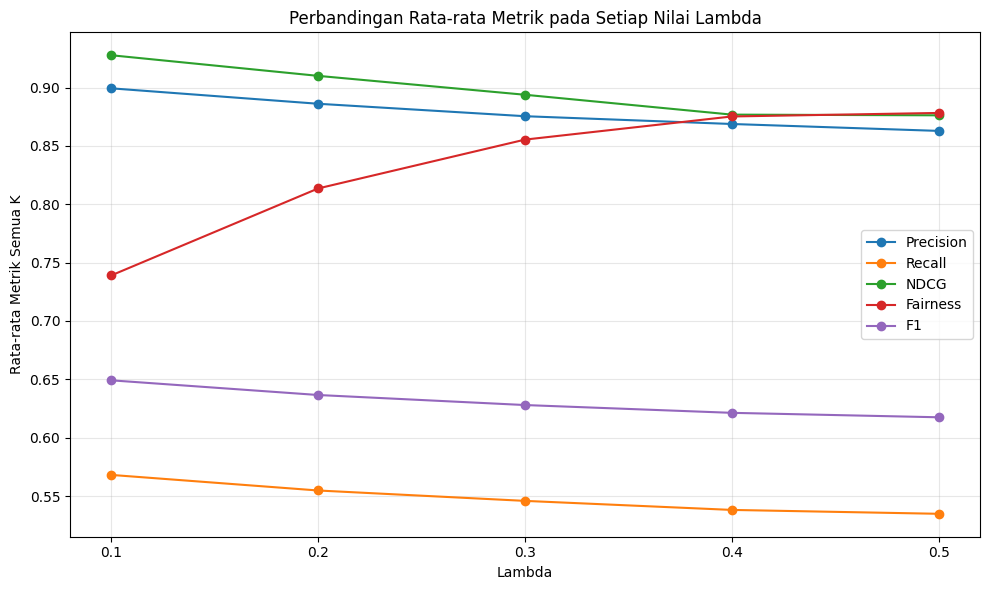

Plot disimpan ke: analysis_fairness_lambda_outputs\04_lambda_metric_comparison.png


In [8]:
plot_cols = [
    "avg_precision_allK",
    "avg_recall_allK",
    "avg_ndcg_allK",
    "avg_fairness_allK",
    "avg_f1_allK",
]

plot_labels = ["Precision", "Recall", "NDCG", "Fairness", "F1"]

plt.figure(figsize=(10, 6))

for col, label in zip(plot_cols, plot_labels):
    plt.plot(
        lambda_summary["lambda"],
        lambda_summary[col],
        marker="o",
        label=label,
    )

plt.title("Perbandingan Rata-rata Metrik pada Setiap Nilai Lambda")
plt.xlabel("Lambda")
plt.ylabel("Rata-rata Metrik Semua K")
plt.xticks(lambda_summary["lambda"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

output_path = OUTPUT_DIR / "04_lambda_metric_comparison.png"
plt.savefig(output_path, dpi=200)
plt.show()

print("Plot disimpan ke:", output_path)
